# LLM Alignment: Preference Tuning (Human Preferences)

## Motivation: Why Preference Tuning?

After:
1. **Pre-training** → learns language
2. **Supervised Fine-Tuning (SFT)** → becomes helpful

The model may still:
- Have **undesirable tone**
- Be **unsafe**
- Be **unfriendly**
- Give responses humans dislike

👉 We need a **third stage** to align the model with **human preferences**

This stage is called **Preference Tuning**

---

## What is Preference Tuning?

- Input: a **prompt**
- Output: **multiple responses**
- Human (or model) provides **preferences** between responses

Instead of teaching:
> “Generate this exact answer”

We teach:
> “Prefer response A over response B”

---

## Example

### Prompt
> Suggest a new activity to do with my teddy bear

### Undesired Response (❌)
> "I would suggest you not spend much time with your teddy bear at all."

### Preferred Response (✅)
> "Teddy bears make great companions! You can play games, read stories, or take them on adventures."

➡️ This forms a **preference pair**

---

## Preference Pair Definition

Given a prompt **x**:

- **y⁺** → preferred response
- **y⁻** → rejected response

Stored as:
$$
(x, y^{+}, y^{-})
$$

This data is **much easier to collect** than SFT data.

---

## Why Not Fix Everything with SFT?

### 1️⃣ Data Creation Difficulty
- SFT requires **high-quality, perfect answers**
- Writing ideal responses is:
  - Time-consuming
  - Expensive
  - Human-intensive

Preference tuning only requires:
> “Which response is better?”

---

### 2️⃣ Prompt Distribution Sensitivity

- SFT is **sensitive to prompt distribution**
- Adding many similar prompts:
  - Biases the model
  - Skews behavior unintentionally

Preference tuning:
- Adds **relative judgments**
- Less sensitive to exact prompt frequency

---

### 3️⃣ High Cost of SFT Data

- SFT data must be:
  - Fluent
  - Helpful
  - Safe
  - Consistent
- Very expensive to curate

Preference tuning:
- Allows fast correction of model behavior
- Does **not require rewriting full answers**

---

## Key Difference: SFT vs Preference Tuning

| Aspect | SFT | Preference Tuning |
|-----|-----|----------------|
| Signal type | Positive only | Positive + Negative |
| Data | Input → Ideal Output | Prompt → Preferred vs Rejected |
| Teaches model | What to say | What to prefer |
| Fixes tone/safety | Limited | Strong |
| Cost | High | Lower |

---

## Important Property: Negative Signal

- **SFT cannot say what is wrong**
- Preference tuning explicitly teaches:
  - ❌ What the model should NOT generate
  - ✅ What it should prefer instead

This is critical for:
- Safety
- Politeness
- Tone
- User satisfaction

---

## Is Preference Tuning a Replacement for SFT?

❌ No

If the model misbehaves **frequently**, it may indicate:
- Poor SFT data
- Bad prompt distribution
- Missing task coverage

👉 Preference tuning **refines behavior**, it does not fix broken SFT.

---

## Relationship with LoRA

- Preference tuning uses a **different objective function**
- Parameter-efficient methods like **LoRA can still be used**
- LoRA ≠ preference tuning  
  - LoRA → *how many parameters to train*
  - Preference tuning → *what loss to optimize*

They are **compatible**.

---

## High-Level Training Pipeline

1. **Pre-training**
   - Learn language structure
2. **Supervised Fine-Tuning (SFT)**
   - Learn to follow instructions
3. **Preference Tuning**
   - Learn human-aligned behavior
   - Inject negative feedback

---

## Key Takeaways

- Preference tuning aligns models with **human values**
- Uses **comparisons**, not perfect answers
- Easier and cheaper than SFT
- Enables:
  - Tone control
  - Safety alignment
  - Helpfulness refinement
- Essential step in **modern LLM alignment**


# Preference Data Collection for Alignment

## Goal
To align a model with **human preferences**, we first need a dataset of **preference pairs**.

Each data point answers the question:
> “Given the same prompt, which response is better?”

---

## Preference Data Setup

Given:
- Prompt: $( x $) (e.g., *“Write a poem”*)
- Multiple candidate responses generated by a model

We must decide **which response is preferred**.

---

## Three Ways to Collect Preference Signals

### 1️⃣ Pointwise Preference (Score-based)

- Each response is scored **independently**
- Example:
  - Poem A → 0.9
  - Poem B → 0.2

#### Problems
- Humans struggle to give **absolute scores**
- Scale is subjective and inconsistent
- Hard to calibrate across annotators

👉 Rarely used in practice

---

### 2️⃣ Pairwise Preference (Most Common)

- Compare **two responses at a time**
- Question:
  > “Which response is better?”

#### Output
- Binary decision:
  - Response A > Response B
  - or Response B > Response A

#### Why Pairwise Works Best
- Easier for humans
- Lower cognitive load
- More consistent judgments
- Scales well

👉 **Industry standard for preference tuning**

---

### 3️⃣ Listwise Preference (Ranking)

- Rank multiple responses (n > 2)
- Example:
  - Best → Worst ordering of poems

#### Trade-offs
- Easier than pointwise
- Harder than pairwise
- More expensive and slower

👉 Less commonly used

---

## Chosen Approach: Pairwise Preference

For the rest of the alignment pipeline:
- We assume **pairwise preference data**
- Each example contains:
$$
(x, y^{+}, y^{-})
$$

Where:
- $( x $) = prompt
- $( y^{+} $) = preferred response
- $( y^{-} $) = rejected response

---

## How Do We Generate Preference Pairs?

### Step 1: Prompt Selection
- Prompt $( x $) sampled from:
  - User logs
  - Synthetic prompt sets
  - Desired task distribution

Important:
- Prompt distribution should match **real user queries**

---

### Step 2: Generate Multiple Responses

- Use the **same model**
- Sample with **temperature > 0**
- Run the prompt multiple times

This gives:
- $( (x, y_1) $)
- $( (x, y_2) $)

Different outputs due to stochastic sampling.

---

### Step 3: Compare Responses

Now decide:
$$
y_1 \succ y_2 \quad \text{or} \quad y_2 \succ y_1
$$

---

## How Are Responses Compared?

### 1️⃣ Human Annotation
- Most reliable
- Expensive
- Slow

---

### 2️⃣ LLM-as-a-Judge
- Use a stronger or same model to compare
- Common in modern pipelines
- Faster and scalable

(Details covered in later lectures)

---

### 3️⃣ Automatic Metrics (Rare Today)
- BLEU
- ROUGE
- Similarity-based rules

⚠️ Not ideal for:
- Creativity
- Helpfulness
- Safety
- Tone

---

## Binary vs Graded Preferences

### Binary Preference (Most Used)
- Preferred vs Rejected
- Simple
- Robust

### Graded Preference (Optional)
- Much better
- Better
- Slightly better
- Slightly worse
- Worse

#### Challenges
- Subjective scale
- Annotator disagreement
- Harder to model

👉 Most systems use **binary preferences**

---

## Alternative Source of Preference Data

### Rewrite-based Preferences

- Take a **bad response**
- Rewrite it into a **better response**
- Treat rewritten version as preferred

Example:
- Original → bad
- Rewritten → good

Pros:
- Direct correction
- Strong signal

Cons:
- More generation cost
- More human effort

---

## Final Preference Dataset Structure

Each training example:
$$
(x, y^{+}, y^{-})
$$

Collected via:
- Sampling + comparison
- Logs + rewriting
- Humans or LLM judges

---

## What Comes Next?

Now that we have:
- Preference pairs
- Preferred vs rejected signals

Next step:
👉 **Train the model to prefer $( y^{+} $) over $( y^{-} $)**

This leads to:
- **RLHF (Reinforcement Learning from Human Feedback)**

---

## Key Takeaways

- Pairwise preference data is the **gold standard**
- Easier to collect than SFT data
- Enables learning from **relative quality**
- Foundation for RLHF and modern alignment


# RLHF: Reinforcement Learning from Human Feedback (Foundations)

## Why RLHF?
After **SFT**, a model:
- Knows how to follow instructions
- Produces reasonable outputs

But it may still:
- Have poor tone
- Be unsafe
- Be misaligned with human preferences

👉 RLHF is used to **align model behavior with human preferences**

---

## RL Basics (Very Light Introduction)

### Core RL Components
- **Agent**: entity that takes actions  
- **Environment**: world the agent interacts with  
- **State** $( s_t $): situation at time $( t $)  
- **Action** $( a_t $): decision taken at time $( t $)  
- **Policy** $( \pi_\theta(a_t \mid s_t) $): probability of action given state  
- **Reward** $( r $): feedback signal

Goal:
$$
\max_\theta \mathbb{E}\left[\sum_t r_t\right]
$$

---

## Mapping RL Concepts to LLMs

| RL Concept | LLM Equivalent |
|----------|----------------|
| Agent | LLM |
| State $( s_t $) | Input tokens so far |
| Action $( a_t $) | Next token |
| Policy $( \pi_\theta $) | Next-token probability distribution |
| Environment | Vocabulary + prompt context |
| Reward | Preference signal |

---

## Policy in LLMs

The policy is:
$$
\pi_\theta(a \mid s) = P_\theta(\text{next token} = a \mid \text{input } s)
$$

- Fully defined by the LLM forward pass
- Sampling = action selection

---

## Reward Signal in RLHF

Important distinction:
- **SFT** → dense supervision (token-level)
- **RLHF** → sparse supervision (sequence-level)

In RLHF:
- Reward is given **after the full response**
- Not per token

👉 This makes RLHF **sparse but high-level**

---

## Two-Stage RLHF Pipeline

### Stage 1: Train a Reward Model (RM)
- Learn what humans **prefer**
- Converts preference data → scalar reward

### Stage 2: Reinforcement Learning
- Optimize LLM policy to maximize reward
- Usually via PPO (later)

---

## Stage 1: Reward Model (RM)

### Goal
Train a model that assigns **higher scores** to preferred responses.

---

## Reward Model Input / Output

**Input**
$$
(x, y)
$$
- $( x $): prompt
- $( y $): response

**Output**
$$
r_\phi(x, y) \in \mathbb{R}
$$
- Scalar score
- Higher = better

---

## Training Data for Reward Model

From preference dataset:
$$
(x, y^+, y^-)
$$

Where:
- $( y^+ $): preferred response
- $( y^- $): rejected response

---

## Reward Model Objective (Intuition)

We want:
$$
r(x, y^+) > r(x, y^-)
$$

Not absolute scores — **relative ranking**

---

## Bradley–Terry Preference Model

We model probability that $( y^+ $) is preferred over $( y^- $):

$$
P(y^+ \succ y^- \mid x) =
\frac{\exp(r_\phi(x, y^+))}{\exp(r_\phi(x, y^+)) + \exp(r_\phi(x, y^-))}
$$

This is equivalent to:
$$
P = \sigma\big(r_\phi(x, y^+) - r_\phi(x, y^-)\big)
$$

Where:
- $( \sigma $) = sigmoid

---

## Reward Model Loss

Binary cross-entropy loss:

$$
\mathcal{L}_{RM} =
- \mathbb{E}_{(x, y^+, y^-)}
\left[
\log \sigma\big(r_\phi(x, y^+) - r_\phi(x, y^-)\big)
\right]
$$

Interpretation:
- Encourage higher reward for preferred outputs
- Penalize bad outputs

---

## Reward Model Architecture

- Typically **same architecture as base LLM**
- Often:
  - Initialize from SFT model
  - Replace LM head with scalar head

---

## Important Properties of Reward Models

- Context-aware (prompt + response)
- Learns **relative preferences**
- Can generalize beyond labeled pairs
- Imperfect and noisy

---

## RLHF vs SFT Signals

| Aspect | SFT | RLHF |
|-----|----|-----|
| Supervision | Token-level | Sequence-level |
| Signal density | Dense | Sparse |
| Teaches what to say | ✅ | ❌ |
| Teaches what to avoid | ❌ | ✅ |

---

## Human Feedback vs AI Feedback

- **RLHF**:
  - Human-annotated preferences
- **RLAIF**:
  - AI-generated preferences (LLM-as-judge)

Both use same math.

---

## Why Not Use Reward Model Directly?

Reward model:
- Scores outputs
- Does NOT generate text

We need:
👉 A **policy** that generates responses **aligned with rewards**

➡️ This leads to **Reinforcement Learning step**

---


# Preference Modeling with Bradley–Terry Formulation (Reward Model Training)

## Pairwise Preference Setup

Given:
- Prompt: $( x $)
- Two responses:
  - Winning response: $( y_w $)
  - Losing response: $( y_l $)

Goal:
- Learn a **reward model** that assigns:
  $$
  r(x, y_w) > r(x, y_l)
  $$

---

## Bradley–Terry Preference Model

Probability that response $( y_i $) is preferred over $( y_j $):

$$
P(y_i \succ y_j) =
\frac{\exp(r_i)}{\exp(r_i) + \exp(r_j)}
$$

Where:
- $( r_i = r(x, y_i) $)
- $( r_j = r(x, y_j) $)

---

### Sigmoid Form

The Bradley–Terry formulation can be rewritten as:

$$
P(y_i \succ y_j) = \sigma(r_i - r_j)
$$

Where:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

---

## Sigmoid Interpretation

- If $( r_i \gg r_j $):
  $$
  \sigma(r_i - r_j) \approx 1
  $$
- If $( r_i \ll r_j $):
  $$
  \sigma(r_i - r_j) \approx 0
  $$

👉 Training objective:
- Increase $( r(x, y_w) $)
- Decrease $( r(x, y_l) $)

---

## Reward Model Architecture

- Input: concatenation of **prompt + response**
  $$
  (x, y)
  $$
- Output: **single scalar reward**
  $$
  r(x, y) \in \mathbb{R}
  $$

Important:
- Reward model is **pointwise**
- Training signal is **pairwise**

---

## Likelihood over Preference Dataset

Given preference dataset:
$$
\mathcal{D} = \{(x^{(k)}, y_w^{(k)}, y_l^{(k)})\}_{k=1}^N
$$

Assume independence between samples.

Likelihood:
$$
\mathcal{L} =
\prod_{k=1}^{N}
\sigma\Big(
r(x^{(k)}, y_w^{(k)}) - r(x^{(k)}, y_l^{(k)})
\Big)
$$

---

## Log-Likelihood

To avoid numerical instability, take log:

$$
\log \mathcal{L} =
\sum_{k=1}^{N}
\log \sigma\Big(
r(x^{(k)}, y_w^{(k)}) - r(x^{(k)}, y_l^{(k)})
\Big)
$$

---

## Reward Model Loss Function

Machine learning convention → **minimize loss**


$$
\mathcal{L}_{RM} =
- \mathbb{E}_{(x, y_w, y_l)}
\left[
\log \sigma\big(
r(x, y_w) - r(x, y_l)
\big)
\right]
$$

This is:
- Pairwise
- Binary cross-entropy–like
- Logistic ranking loss

---

## Key Properties of Reward Model Training

- Training is **pairwise**
- Inference is **pointwise**
- Model learns **relative ordering**, not absolute scores
- Output scale is **free-form** (later normalized if needed)

---

## Reward Model Characteristics

- Same backbone as LLM (decoder-only commonly)
- Final head outputs scalar reward
- Can score **any (prompt, response)** pair

---

## Reward Interpretation (Intuition)

Typical (not enforced):
- Good response → positive score
- Bad response → negative score

Example:
- $( r = +1.2 $) → preferred
- $( r = -2.1 $) → dispreferred

Only **differences** matter:
$$
r(x, y_w) - r(x, y_l)
$$

---

## Notes on Labels & Noise

- Preference labels usually **binary**
- Human annotations are subjective
- Clear annotation guidelines are critical
- Noisy labels directly affect reward quality

---

## Outcome of This Stage

After training:
- Reward Model $( r_\phi(x, y) $) is obtained
- Used as **reward function** in RL step
- Does **not** generate text
- Only evaluates responses

---



# Preference Tuning with Reinforcement Learning (RLHF – Policy Optimization)

## Setup Recap

We have:
- A **base LLM**:
  - Pre-trained
  - Supervised Fine-Tuned (SFT)
- A **reward model** $( r_\phi(x, y) $):
  - Trained using preference pairs
  - Frozen during this stage

Goal:
- Align the **LLM policy** with human preferences
- Use **reinforcement learning**
- Avoid deviating too far from the SFT model

---

## Terminology

- Prompt: $( x $)
- Completion / rollout: $( y = (y_1, \dots, y_T) $)
- Policy (LLM):
  $$
  \pi_\theta(y \mid x)
  $$
- Reference policy (SFT model):
  $$
  \pi_{\text{ref}}(y \mid x)
  $$

---

## Rollout Generation

1. Sample prompt $( x $)
2. Generate full response $( y \sim \pi_\theta(\cdot \mid x) $)
3. Evaluate reward:
   $$
   r_\phi(x, y)
   $$

Reward is:
- Scalar
- Given for the **entire completion**
- Not token-level

---

## Why We Need Regularization

We **do not** want to:
- Forget knowledge learned during pre-training
- Overfit noisy reward model
- Exploit reward model imperfections (reward hacking)
- Introduce training instability

Solution:
👉 Penalize deviation from reference policy

---

## KL Regularization

Measure deviation using KL divergence:

$$
\mathrm{KL}\big(\pi_\theta(\cdot \mid x) \;\|\; \pi_{\text{ref}}(\cdot \mid x)\big)
$$

This ensures:
- Policy stays close to SFT model
- Stable learning
- Prevents reward hacking

---

## KL at Token Level

For autoregressive models:

$$
\mathrm{KL} =
\sum_{t=1}^{T}
\mathbb{E}_{y_t \sim \pi_\theta}
\left[
\log \frac{\pi_\theta(y_t \mid x, y_{<t})}
{\pi_{\text{ref}}(y_t \mid x, y_{<t})}
\right]
$$

---

## RL Objective (Unconstrained Form)

We want to maximize:

$$
\mathbb{E}_{x, y \sim \pi_\theta}
\left[
r_\phi(x, y)
- \beta \,
\mathrm{KL}
\big(
\pi_\theta(\cdot \mid x)
\;\|\;
\pi_{\text{ref}}(\cdot \mid x)
\big)
\right]
$$

Where:
- $( \beta $) = KL penalty coefficient

---

## Equivalent Reward-Shaped Objective

Define modified reward:

$$
\tilde{r}(x, y)
=
r_\phi(x, y)
-
\beta \sum_{t=1}^{T}
\log \frac{\pi_\theta(y_t \mid x, y_{<t})}
{\pi_{\text{ref}}(y_t \mid x, y_{<t})}
$$

This converts the problem into standard RL.

---

## Policy Gradient Objective

Maximize expected shaped reward:

$$
\mathcal{J}(\theta)
=
\mathbb{E}_{x, y \sim \pi_\theta}
\big[
\tilde{r}(x, y)
\big]
$$

Gradient:

$$
\nabla_\theta \mathcal{J}
=
\mathbb{E}
\left[
\nabla_\theta \log \pi_\theta(y \mid x)
\cdot
\tilde{r}(x, y)
\right]
$$

---

## PPO (Proximal Policy Optimization)

To stabilize training, PPO introduces a clipped objective.

### Probability Ratio

$$
\rho_t(\theta)
=
\frac{
\pi_\theta(y_t \mid x, y_{<t})
}{
\pi_{\text{old}}(y_t \mid x, y_{<t})
}
$$

---

### Advantage Function

$$
A_t =
\tilde{r}(x, y) - b(x)
$$

Where:
- $( b(x) $) = baseline (e.g., value model)

---

### PPO Clipped Objective

$$
\mathcal{L}_{\text{PPO}} =
\mathbb{E}
\left[
\min
\Big(
\rho_t A_t,
\text{clip}(\rho_t, 1-\epsilon, 1+\epsilon) A_t
\Big)
\right]
$$

---

## Full PPO-RLHF Loss

$$
\mathcal{L}
=
\mathcal{L}_{\text{PPO}}
-
\beta \,
\mathrm{KL}
\big(
\pi_\theta
\;\|\;
\pi_{\text{ref}}
\big)
$$

---

## Key Characteristics of RLHF Training

- Reward model is **frozen**
- LLM is **trainable**
- Signals are **sparse** (one reward per completion)
- Training data: ~100K+ rollouts
- KL penalty prevents:
  - Reward hacking
  - Catastrophic forgetting

---

## Intuition Summary

- Reward → *what humans prefer*
- KL → *do not forget what you know*
- PPO → *stable optimization*

---

## Outcome

After this stage:
- Model is **aligned**
- More helpful, safe, and human-preferred
- This completes **alignment training**


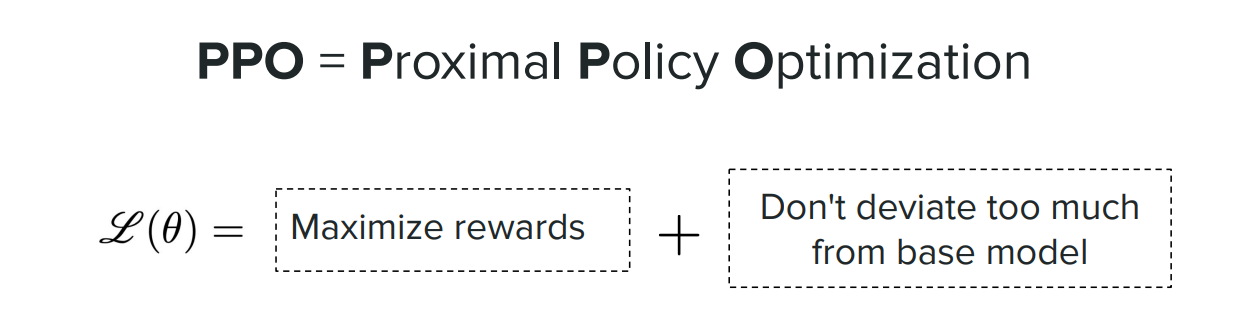

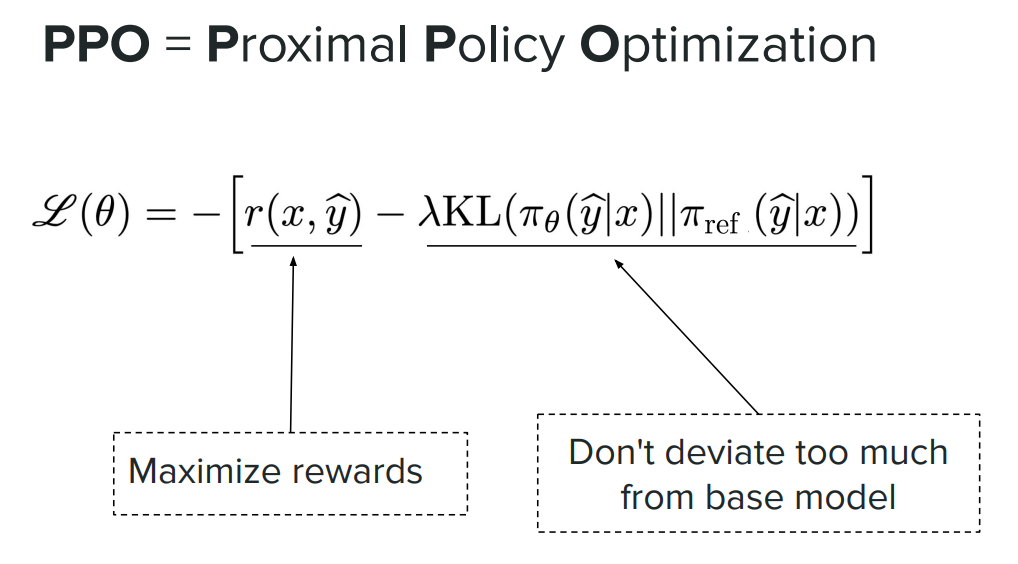

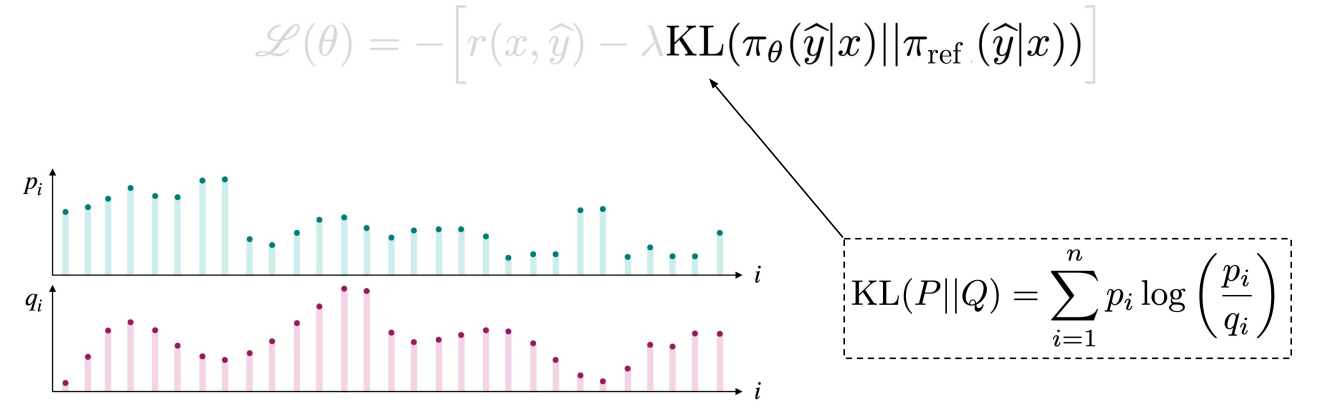

# Preference Tuning with PPO (Proximal Policy Optimization)

## Why PPO is Used in RLHF

- We want to **align the LLM policy** with human preferences
- But we **must not deviate too much** from the SFT model
- PPO provides:
  - Stable optimization
  - Controlled policy updates
  - Explicit constraint on deviation from base policy

Reference model:
- The **SFT model** (frozen)
- Denoted as:
$$
\pi_{\text{ref}}
$$

Trainable model:
$$
\pi_\theta
$$

---

## PPO Objective (High-Level)

The loss has **two competing terms**:

1. **Reward maximization**
2. **KL regularization** (excessive deviation penalty)

Conceptually:
$$
\text{Objective} = \text{Reward} - \beta \cdot \text{KL divergence}
$$

---

## KL Divergence

KL divergence measures how far two probability distributions are.

Given:
- Policy $(P$)
- Reference $(Q$)

$$
\mathrm{KL}(P \| Q)
=
\sum_i P(i) \log \frac{P(i)}{Q(i)}
$$

Properties:
- $( \mathrm{KL} \ge 0 $)
- $( \mathrm{KL} = 0 \iff P = Q $)
- Proven using **Jensen’s inequality**
- Not symmetric → **not a distance**

In RLHF:
$$
\mathrm{KL}\big(\pi_\theta \;\|\; \pi_{\text{ref}}\big)
$$

---

## Why KL Regularization is Necessary

Without KL penalty:
- ❌ Catastrophic forgetting
- ❌ Reward hacking
- ❌ Overfitting to noisy reward model
- ❌ Training instability

KL ensures:
- Policy stays **proximal** to base model
- Core language abilities are preserved

---

## Reward vs Advantage

Important correction:

❌ We do **NOT** maximize raw reward  
✅ We maximize **advantage**

---

## Reward Function

From reward model:
$$
r(x, y)
$$

- Given **prompt + full completion**
- Scalar
- Sparse (1 reward per rollout)

---

## Value Function

Value function estimates **expected future reward** from a partial sequence.

$$
V_\phi(x, y_{<t})
$$

---
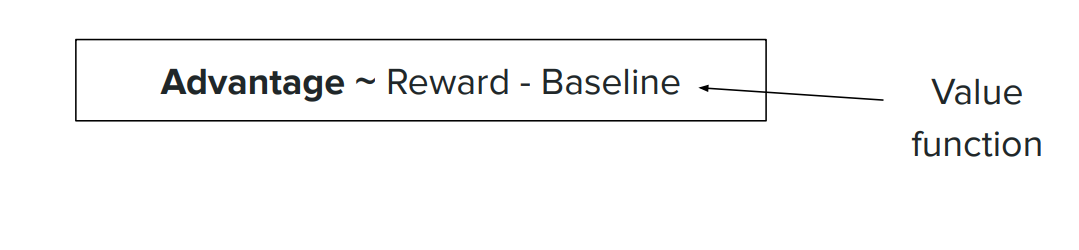
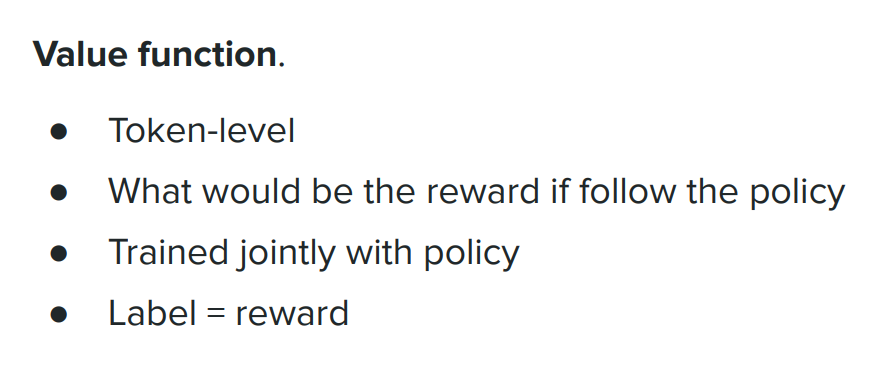


---

Meaning:
- Input: prompt + partial generation
- Output: expected final reward **if policy continues**

Key properties:
- Token-level estimation
- Regression task
- Trained jointly with policy
- Implemented as a **value head** on LLM

---

## Advantage Function

Advantage measures:
> *How much better this output is compared to expectation*

$$
A_t = r(x, y) - V_\phi(x, y_{<t})
$$

Why use advantage?
- Reduces variance
- Stabilizes learning
- Faster convergence

---

## Generalized Advantage Estimation (GAE)

In practice:
- Advantage is estimated using **GAE**
- Combines:
  - Multiple time steps
  - Discounting
  - Bias–variance tradeoff

Formal definition omitted (out of scope)

Reference:
> *High-Dimensional Continuous Control Using Generalized Advantage Estimation*

---

## PPO Probability Ratio

To prevent large policy updates:

$$
r_t(\theta)
=
\frac{
\pi_\theta(y_t \mid x, y_{<t})
}{
\pi_{\text{old}}(y_t \mid x, y_{<t})
}
$$

- Measures how much policy changed
- Compared to previous iteration

---

## PPO Clipped Objective

$$
\mathcal{L}_{\text{PPO}}
=
\mathbb{E}
\Big[
\min
\big(
r_t(\theta) A_t,
\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) A_t
\big)
\Big]
$$

---
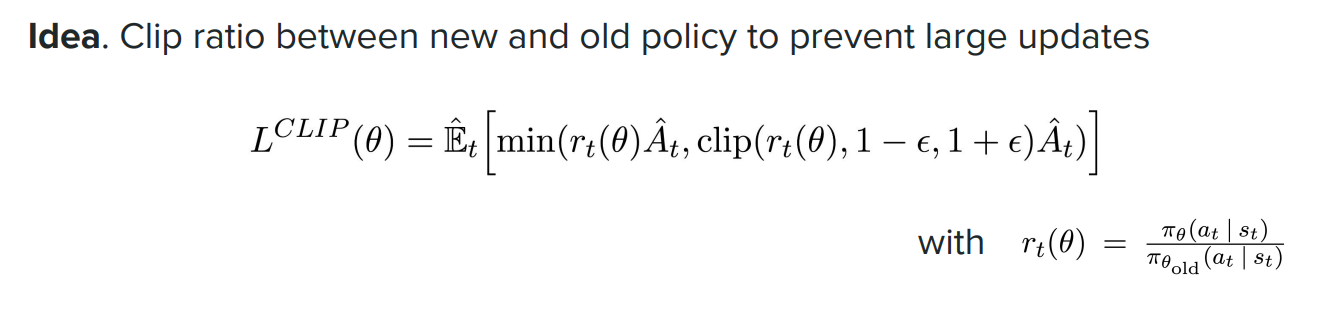

---

Purpose:
- Prevent overly large updates
- Maintain training stability

---

## Final PPO-RLHF Loss

$$
\mathcal{L}
=
\mathcal{L}_{\text{PPO}}
-
\beta \,
\mathrm{KL}
\big(
\pi_\theta
\;\|\;
\pi_{\text{ref}}
\big)
$$

Where:
- $( \beta $) controls strength of KL penalty

---

## Training Summary

During PPO-based RLHF:
- Reward model → **frozen**
- Reference policy → **frozen**
- Policy + value head → **trainable**
- Advantage used instead of raw reward
- KL penalty prevents reward hacking

---

## Key Intuition

- **Reward** → what humans prefer
- **Value function** → expected reward
- **Advantage** → relative improvement
- **KL** → stay close to SFT model
- **PPO** → stable optimization


## PPO Loss Functions in RLHF 

Preference tuning with RLHF optimizes a policy (LLM) to **increase human-preferred outputs**
while **preventing destructive updates** to a well-trained base model.

This is achieved using **Proximal Policy Optimization (PPO)**.

---

## Core Quantities Recap

### Policy
The LLM defines a policy:

$$
\pi_\theta(a_t \mid s_t)
$$

- $s_t$: current state (prompt + tokens generated so far)
- $a_t$: action (next token)
- $\theta$: trainable LLM parameters

---

### Probability Ratio

$$
R_t(\theta)
=
\frac{\pi_\theta(a_t \mid s_t)}
{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}
$$

- Measures **how much the policy changed**
- $\theta_{\text{old}}$ = parameters from **previous PPO iteration**
- NOT the reward model  
- NOT the SFT model

Purpose:
- Control **update size**
- Ensure **training stability**

---

### Reward vs Advantage

#### Reward
- Comes from the **reward model**
- Scalar score for a *complete response*
- Example: $r \in \{-2, 0, +1\}$

#### Value Function

$$
V_\phi(s_t)
$$

- Predicts **expected future reward**
- Trained jointly with policy
- Token-level estimation

---

### Advantage

$$
A_t = R_t - V_\phi(s_t)
$$

Interpretation:
- $A_t > 0$ → output better than expected → reinforce
- $A_t < 0$ → output worse than expected → suppress

Advantage reduces variance and stabilizes training.

---

## PPO-Clip Objective

### Formula

$$
\mathcal{L}_{\text{PPO-Clip}}(\theta)
=
\mathbb{E}\Big[
\min\Big(
R_t(\theta)\,A_t,
\;\text{clip}\big(R_t(\theta),\,1-\epsilon,\,1+\epsilon\big)\,A_t
\Big)
\Big]
$$

> ⚠️ Despite being called a “loss”, this objective is **maximized**.

---

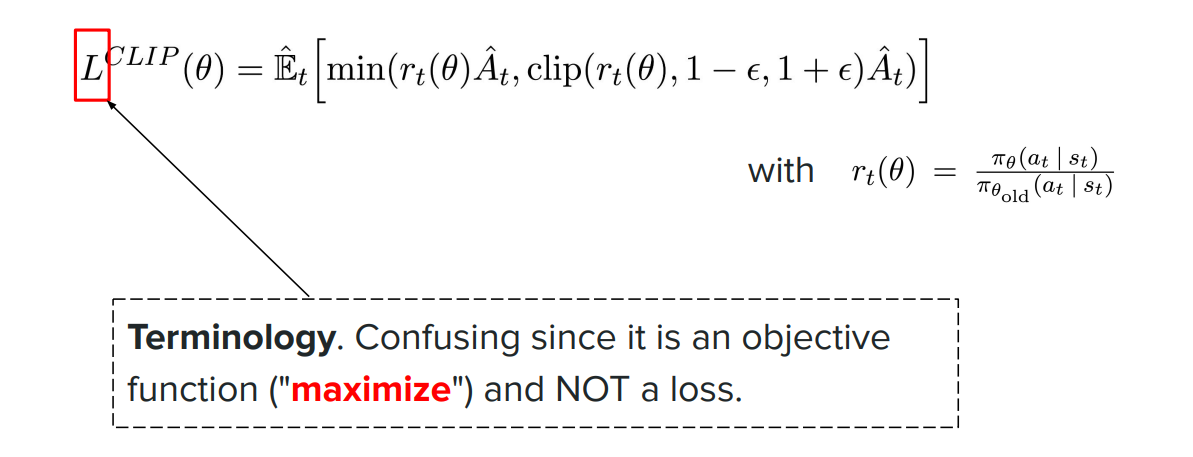

---

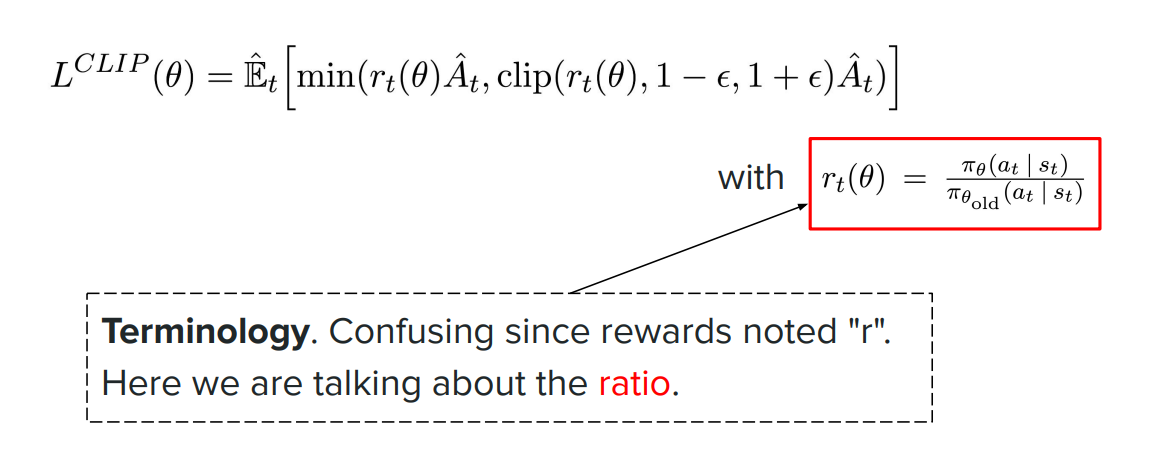
---

### Why Clipping?

Clipping constrains how much the policy is allowed to change.

---

### Case 1: Positive Advantage ($A_t > 0$)

Goal:
- Increase probability of this action

Without clipping:
- Policy could increase probability **too aggressively**

With clipping:
- Once $R_t > 1+\epsilon$, improvement is capped

Effect:
- Encourages learning
- Prevents instability

---

### Case 2: Negative Advantage ($A_t < 0$)

Goal:
- Decrease probability of this action

Without clipping:
- Policy could suppress action too much

With clipping:
- Once $R_t < 1-\epsilon$, suppression is capped

Effect:
- Avoids catastrophic forgetting
- Prevents overreaction to noisy rewards

---

## PPO with KL Penalty

Instead of clipping, deviation can be controlled using KL divergence.

---

### KL-Penalized Objective

$$
\mathcal{L}_{\text{PPO-KL}}(\theta)
=
\mathbb{E}\Big[
R_t(\theta)\,A_t
-
\beta\,
\text{KL}\big(
\pi_\theta \,\|\, \pi_{\text{ref}}
\big)
\Big]
$$

Where:

$$
\text{KL}(P \| Q)
=
\sum_i P(i)\log\frac{P(i)}{Q(i)}
$$

---

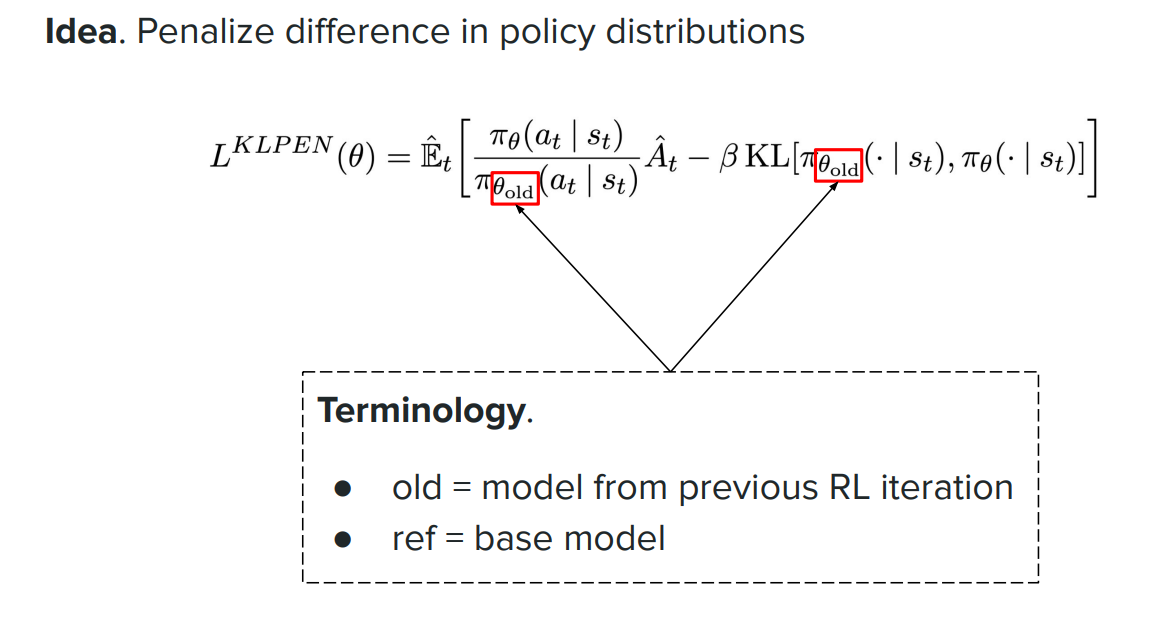

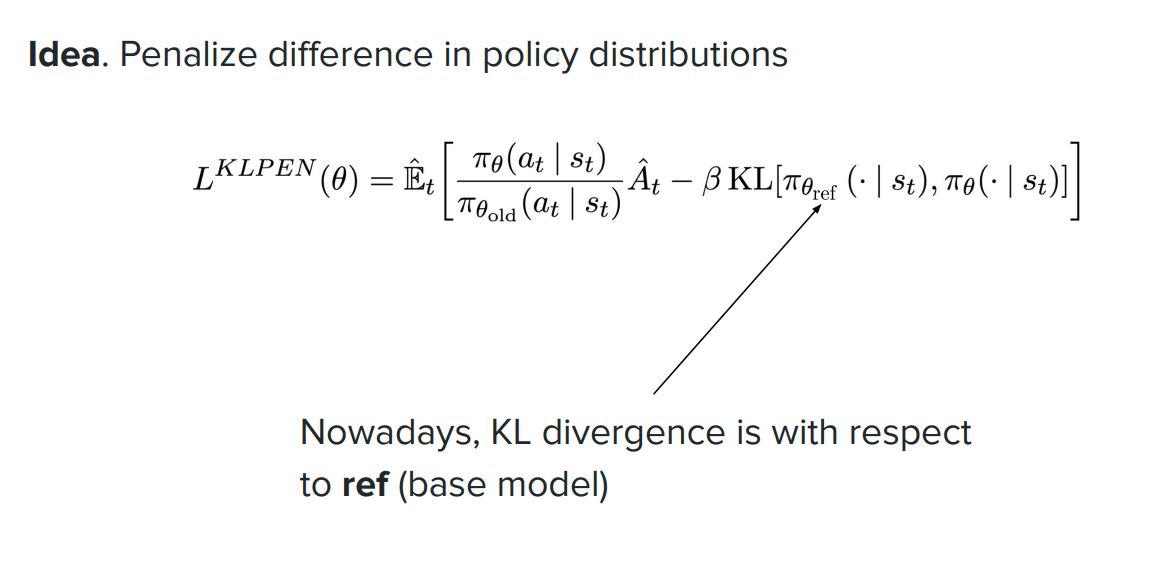

---
### Reference Policy

- $\pi_{\text{ref}}$ is typically the **SFT model**
- Frozen
- Represents *trusted baseline behavior*

---

### Role of KL Penalty

- Prevents **reward hacking**
- Prevents **style drift**
- Preserves linguistic & factual knowledge

---

## Why PPO is Expensive

PPO-based RLHF requires:

- Policy model (LLM)
- Reward model (frozen)
- Value function head
- Reference (SFT) model

➡️ Multiple forward passes per update  
➡️ High memory + compute cost

---

## Practical Reality (2024–2025)

- PPO is **stable but heavy**
- Many implementations:
  - PPO-Clip only
  - KL-penalty only
  - Hybrid PPO (Clip + KL)
- Newer algorithms (e.g. **GRPO**) reduce complexity

---

## Big Picture Takeaway

- PPO balances:
  - Maximizing human preference
  - Preserving base model knowledge
- Advantage-based learning stabilizes updates
- KL regularization prevents reward exploitation
- PPO laid the foundation for modern alignment methods


## Challenges of RL-Based Preference Tuning (RLHF)

While PPO-based RLHF is powerful, it introduces several **practical and conceptual challenges**.

---

## 1️⃣ Two-Stage Dependency Problem

RLHF requires **two sequential training stages**:

1. **Reward Model Training**
2. **Policy Optimization (PPO / RL)**

### Issue
- If the **reward model is flawed**
- Then the **policy optimization is also flawed**
- Fixing the reward model requires:
  - Re-training the reward model
  - Re-running the entire RL stage

This tight dependency makes iteration **slow and costly**.

---

## 2️⃣ Large Number of Hyperparameters

RLHF introduces many sensitive hyperparameters:

### Examples
- PPO-Clip:
  - $\epsilon$ (clipping range)
- PPO-KL:
  - $\beta$ (KL penalty coefficient)
- Generalized Advantage Estimation (GAE):
  - $\gamma$ (discount factor)
  - $\lambda$ (bias–variance tradeoff)

### Problem
- Small changes can cause instability
- Poor tuning → divergence or reward collapse
- Retraining is expensive

---

## 3️⃣ Training Instability

Even with clipping and KL regularization:
- Policy updates can still be unstable
- Reward model noise can amplify errors
- Over-optimization leads to **reward hacking**

### Reward Hacking
The policy learns to exploit **imperfections in the reward model**
instead of genuinely improving usefulness or safety.

---

## 4️⃣ Monitoring Training is Hard

### What metric do we monitor?

- Average reward is commonly used
- But:
  - Higher reward ≠ better real-world behavior
  - Reward model itself may be misaligned

Unlike pre-training or SFT:
- No clean **cross-entropy loss** to track
- No obvious convergence signal

---

## 5️⃣ Exploration vs Exploitation

RL requires **exploration**.

### Problem
- If the model always generates similar outputs:
  - It cannot discover better responses
- If exploration is too high:
  - Outputs become unstable or unsafe

Balancing exploration is difficult:
- Temperature
- Sampling strategies
- Policy entropy regularization

---

## 6️⃣ Conceptual Complexity of RL

RLHF introduces:
- On-policy learning
- Policy ratios
- Advantage estimation
- Value functions

Many practitioners:
- Are unfamiliar with RL
- Find it hard to debug or reason about failures

---

## On-Policy vs Off-Policy (Important Concept)

### Supervised Fine-Tuning (SFT)
- **Off-policy**
- Trains on a fixed dataset
- Model does NOT generate training data

### RLHF (PPO)
- **On-policy**
- Model generates responses
- Training uses those same responses

➡️ Policy is optimized **on its own behavior**

---

## Why Not Just Use SFT on Preference Data?

SFT teaches:
- What the model **should generate**

But SFT **cannot directly teach**:
- What the model **should avoid**

Unless:
- Every bad response is rewritten into a perfect one

RLHF allows:
- Explicit negative signal
- Preference-based learning

---

## Best-of-N (BoN): RL-Free Alternative

To avoid RL complexity, many systems use **Best-of-N decoding**.

---

## Best-of-N (BoN) Algorithm

### Step-by-Step
1. Input prompt $x$
2. Generate $N$ responses:
   $$
   \{y_1, y_2, \dots, y_N\}
   $$
3. Score each response using the reward model:
   $$
   r_i = RM(x, y_i)
   $$
4. Select:
   $$
   y^* = \arg\max_i r_i
   $$

---

## Example (Teddy Bear Prompt)

Prompt:
> Suggest a new activity I could do with my teddy bear

Generated responses:
- $y_1$: Fun indoor game → $r_1 = 0.8$
- $y_2$: “Stop playing with it” → $r_2 = -2.0$
- $y_3$: Picnic idea → $r_3 = 0.3$

Selected output:
$$
y^* = y_1
$$

---

## Advantages of Best-of-N

- No RL training
- No policy instability
- Simple to implement
- Uses reward model directly

---

## Limitations of Best-of-N

### 1️⃣ Inference Cost Explosion
- Requires $N$ generations per prompt
- Expensive for high-traffic systems

### 2️⃣ Depends on Base Model Quality
- If all $N$ outputs are bad → result is bad
- Reward model can only rank what exists

### 3️⃣ Latency Issues
- Slower response times
- Not ideal for real-time systems

---

## Scale Sensitivity

BoN does **not care about reward scale**:
- Only relative ranking matters
- Scaling does not affect $\arg\max$

Scaling **does matter** in RL losses.

---

## Big Picture Comparison

| Method | Training Cost | Inference Cost | Stability |
|------|--------------|---------------|-----------|
| RLHF (PPO) | High | Low | Medium |
| Best-of-N | None | High | High |

---

## Key Takeaways

- RLHF is powerful but complex and expensive
- PPO introduces instability and tuning challenges
- Best-of-N avoids RL but shifts cost to inference
- Practical systems choose based on:
  - Traffic scale
  - Cost constraints
  - Desired alignment quality


## Direct Preference Optimization (DPO)

This section introduces **DPO (Direct Preference Optimization)** as an alternative to
**RLHF with PPO**, motivated by the practical challenges of reinforcement learning–based
alignment.

---

## Motivation: Problems with RL-Based Preference Tuning

From the RLHF + PPO setup, we observed several major issues:

### 1️⃣ Too Many Models in PPO
PPO-based RLHF requires maintaining and coordinating:

- Current policy model $\pi_\theta$
- Reference (base / SFT) model $\pi_{\text{ref}}$
- Reward model $r_\phi$
- Value function $V_\psi$

This significantly increases:
- Memory usage
- Engineering complexity
- Training instability

---

### 2️⃣ Best-of-N (BoN) Is Not a Perfect Solution
BoN avoids RL but shifts the cost to inference.

Even with **infinite compute**:
- Latency increases because we must wait for the **slowest completion**
- The maximum of $N$ generation times shifts latency **to the right**
- Real-time systems suffer

---

### 3️⃣ Core Question
> Why not do **pure supervised learning** on preference data?

This is exactly the question that **DPO** answers.

---

## What Is DPO?

**DPO = Direct Preference Optimization**

Instead of:
- Learning a reward model
- Then optimizing a policy via RL

DPO **directly optimizes the policy** using preference pairs via a **single supervised loss**.

➡️ **No reward model**
➡️ **No value function**
➡️ **No RL loop**

---

## Preference Data Setup (Same as RLHF)

Each data point consists of:

- Prompt: $x$
- Preferred completion: $y_w$ (winner)
- Dispreferred completion: $y_l$ (loser)

Human (or AI) feedback indicates:
$$
y_w \succ y_l
$$

---

## DPO Loss Function

The DPO loss is:

$$
\mathcal{L}_{\text{DPO}}(\theta)
=
-\mathbb{E}_{(x, y_w, y_l)}
\left[
\log \sigma
\left(
\beta
\left(
\log \frac{\pi_\theta(y_w \mid x)}{\pi_{\text{ref}}(y_w \mid x)}
-
\log \frac{\pi_\theta(y_l \mid x)}{\pi_{\text{ref}}(y_l \mid x)}
\right)
\right)
\right]
$$

Where:
- $\pi_\theta$ → current policy being trained
- $\pi_{\text{ref}}$ → frozen reference model (SFT model)
- $\beta$ → KL control coefficient (typically $\approx 0.1$)
- $\sigma(\cdot)$ → sigmoid function

---

## Key Observations About the DPO Loss

### 1️⃣ No Explicit Reward Model
There is **no $r(x,y)$** anywhere in the loss.

Instead:
- Preference signal is encoded **directly in policy probabilities**
- The model itself acts as an implicit reward model

➡️ This is why the paper is titled  
**“Your Language Model Is Secretly a Reward Model”**

---

### 2️⃣ Bradley–Terry Structure Appears Naturally

The inner expression:
$$
\log \pi(y_w \mid x) - \log \pi(y_l \mid x)
$$

is exactly the **logit difference** used in the **Bradley–Terry preference model**:

$$
P(y_w \succ y_l) = \sigma(r_w - r_l)
$$

In DPO:
- $r$ is replaced by **log-probability ratios**
- Rewards are implicit

---

## Where Does DPO Come From? (High-Level Derivation)

### Step 1: PPO Objective (Recall)

PPO aims to solve:
$$
\max_\pi
\;\;
\mathbb{E}[r(x,y)]
-
\beta \, \mathrm{KL}(\pi \;\|\; \pi_{\text{ref}})
$$

---

### Step 2: Solve for the Optimal Policy

Solving this optimization yields:
$$
\pi^*(y \mid x)
\propto
\pi_{\text{ref}}(y \mid x)
\exp\left(\frac{1}{\beta} r(x,y)\right)
$$

---

### Step 3: Express Reward in Terms of Policy

Rearranging:
$$
r(x,y)
=
\beta
\left(
\log \pi^*(y \mid x)
-
\log \pi_{\text{ref}}(y \mid x)
\right)
+ \text{const}
$$

---

### Step 4: Plug into Bradley–Terry Preference Model

For a preference pair $(y_w, y_l)$:
$$
P(y_w \succ y_l)
=
\sigma
\left(
\beta
\left[
\log \frac{\pi(y_w \mid x)}{\pi_{\text{ref}}(y_w \mid x)}
-
\log \frac{\pi(y_l \mid x)}{\pi_{\text{ref}}(y_l \mid x)}
\right]
\right)
$$

---

### Step 5: Maximum Likelihood → Loss

Taking negative log-likelihood gives the **DPO loss**.

➡️ No RL  
➡️ No reward model  
➡️ Pure supervised learning

---

## Comparison: PPO vs DPO

### RLHF with PPO
- Two-stage training
- On-policy RL
- High variance
- Complex tuning
- Best final performance (when tuned well)

---

### DPO
- Single-stage supervised learning
- Stable optimization
- Only two models:
  - $\pi_\theta$
  - $\pi_{\text{ref}}$
- Much easier to implement

---

## Why Isn’t DPO Always Better?

### Distribution Shift
- Preference datasets may not match model-generated distributions
- DPO trains directly on preference pairs
- Can overfit to preference data if not careful

---

### Performance Trade-off
Empirically:
- PPO > DPO in peak performance
- DPO ≈ PPO with much less effort

---

## Practical Guidance

- **Use DPO** when:
  - You want fast, stable preference tuning
  - Compute budget is limited
  - You want simple pipelines

- **Use PPO** when:
  - You want maximum performance
  - You can afford tuning complexity
  - You have strong RL expertise

---

## Intuition: What Preference Tuning Really Does

Preference tuning does **not teach new facts**.

It:
- Adjusts tone
- Improves politeness
- Increases helpfulness
- Aligns style with human expectations

### Example (Teddy Bear)

Instruction-tuned answer:
> “No, it might get damaged. Hand wash it.”

Preference-tuned answer:
> “It’s better not to put it in the washer — your teddy bear could get damaged. A gentle hand wash is much safer.”

Same facts.  
Better alignment.

---

## Final Takeaway

- PPO = powerful but complex
- DPO = simple, elegant, supervised alternative
- Modern systems increasingly favor **DPO-style alignment**

---

